# DevelopersHub Corporation
## Data Science & Analytics Internship — All 5 Tasks
**Due Date:** 15th May 2026

**DHC-2243**

---
This notebook completes all 5 internship tasks:
1. Exploring and Visualizing the Iris Dataset
2. Credit Risk Prediction (Loan Default)
3. Customer Churn Prediction (Bank Customers)
4. Predicting Insurance Claim Amounts
5. Personal Loan Acceptance Prediction

**Libraries used:** `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`


In [28]:
# Global Imports & Settings 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (accuracy_score, confusion_matrix,classification_report, mean_absolute_error,mean_squared_error, r2_score)
from sklearn.datasets import load_iris

sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.dpi'] = 100
print("All libraries imported successfully!")


All libraries imported successfully!


---
# Task 1: Exploring and Visualizing the Iris Dataset

## Introduction
The **Iris dataset** is a classic multivariate dataset introduced by Ronald Fisher in 1936.
It contains **150 samples** of iris flowers across **3 species** (setosa, versicolor, virginica),
each described by 4 features: sepal length, sepal width, petal length, and petal width.

**Objective:** Load, inspect, and visualize the dataset to understand feature distributions and inter-species relationships.


In [29]:
# 1.1 Load the Dataset 
iris_raw = load_iris()
iris = pd.DataFrame(iris_raw.data, columns=['sepal_length','sepal_width','petal_length','petal_width'])
iris['species'] = pd.Categorical.from_codes(iris_raw.target, iris_raw.target_names)

print("Dataset Shape:", iris.shape)
print("Columns:", iris.columns.tolist())
iris.head()


Dataset Shape: (150, 5)
Columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width', 'species']


,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [3]:
# ── 1.2 Dataset Structure & Summary ────────────────────────
print("Data Types:")
print(iris.dtypes)
print("\nMissing Values:", iris.isnull().sum().sum())
print("\nSpecies Distribution:")
print(iris['species'].value_counts())
print("\nStatistical Summary:")
iris.describe()


Data Types:
sepal_length     float64
sepal_width      float64
petal_length     float64
petal_width      float64
species         category
dtype: object

Missing Values: 0

Species Distribution:
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64

Statistical Summary:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


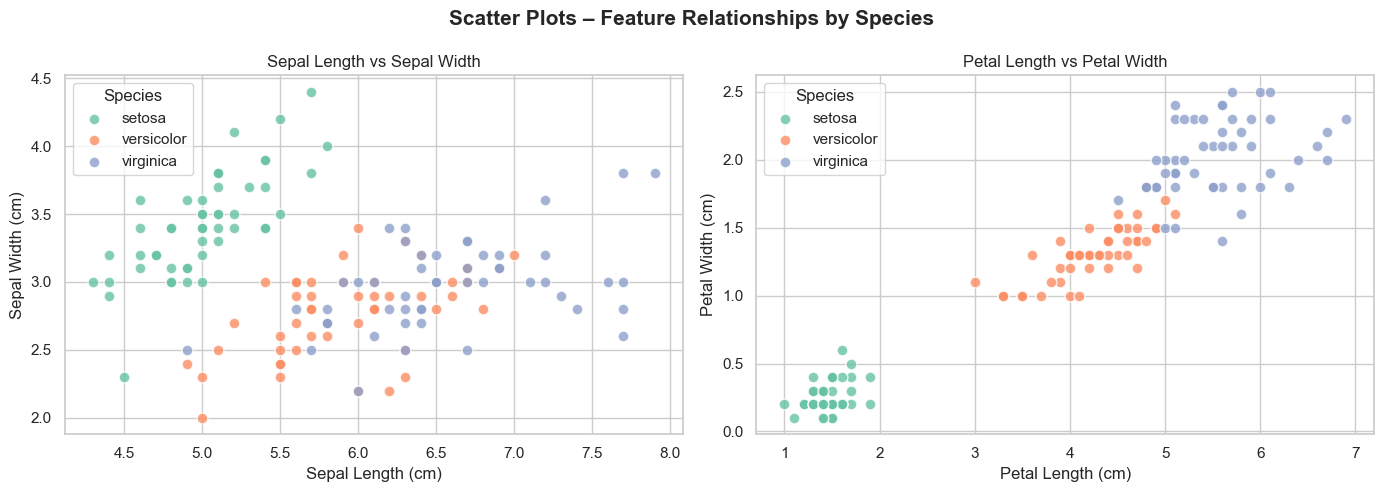

In [30]:
# 1.3 Scatter Plots 
features = ['sepal_length','sepal_width','petal_length','petal_width']
labels   = ['Sepal Length (cm)','Sepal Width (cm)','Petal Length (cm)','Petal Width (cm)']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Scatter Plots – Feature Relationships by Species", fontsize=15, fontweight='bold')

for species, grp in iris.groupby('species'):
    axes[0].scatter(grp['sepal_length'], grp['sepal_width'], label=species, s=60, alpha=0.8, edgecolors='white')
axes[0].set(xlabel='Sepal Length (cm)', ylabel='Sepal Width (cm)', title='Sepal Length vs Sepal Width')
axes[0].legend(title='Species')

for species, grp in iris.groupby('species'):
    axes[1].scatter(grp['petal_length'], grp['petal_width'], label=species, s=60, alpha=0.8, edgecolors='white')
axes[1].set(xlabel='Petal Length (cm)', ylabel='Petal Width (cm)', title='Petal Length vs Petal Width')
axes[1].legend(title='Species')

plt.tight_layout()
plt.show()

# Note: Petal dimensions perfectly separate setosa from the others.

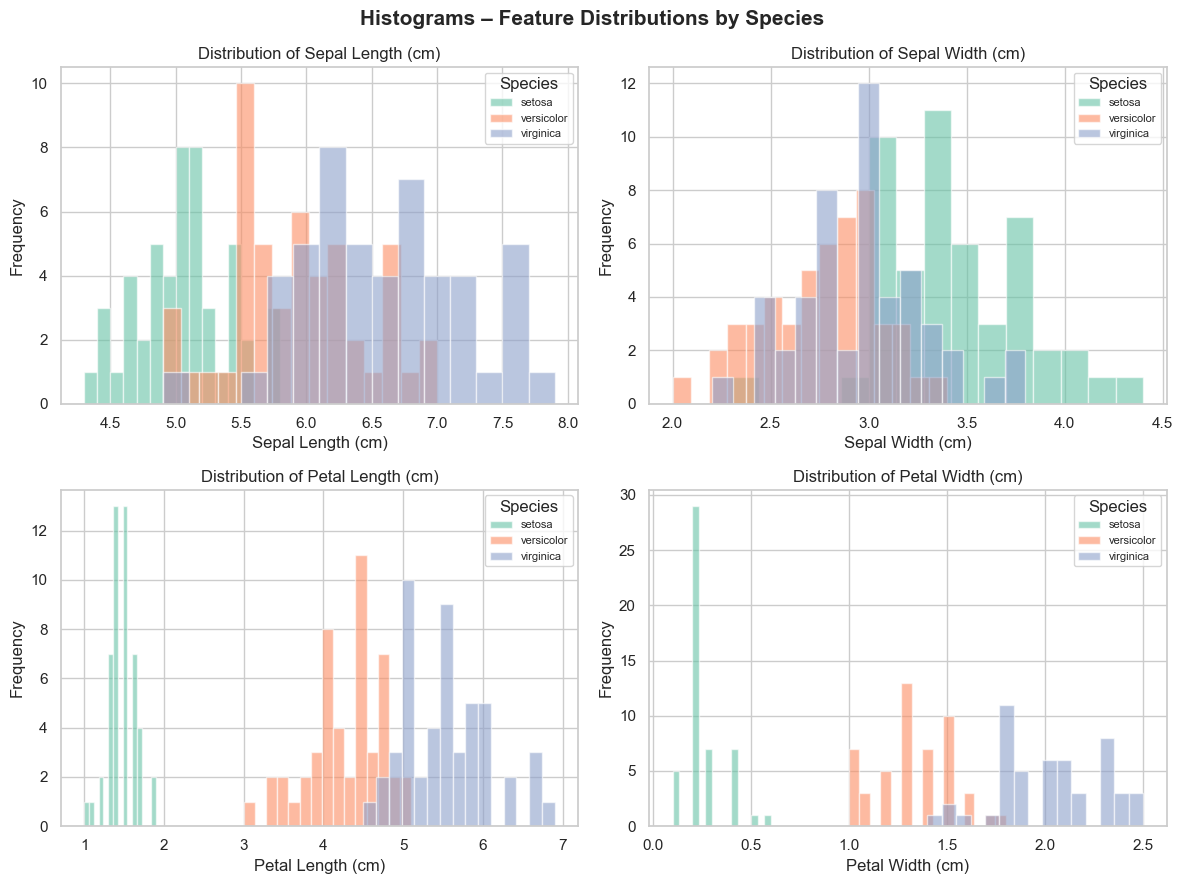

In [32]:
# 1.4 Histograms
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Histograms – Feature Distributions by Species", fontsize=15, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), features, labels):
    for species in iris['species'].unique():
        ax.hist(iris[iris['species']==species][feat], bins=15, alpha=0.6,label=species, edgecolor='white')
    ax.set(xlabel=label, ylabel='Frequency', title=f'Distribution of {label}')
    ax.legend(title='Species', fontsize=8)

plt.tight_layout()
plt.show()


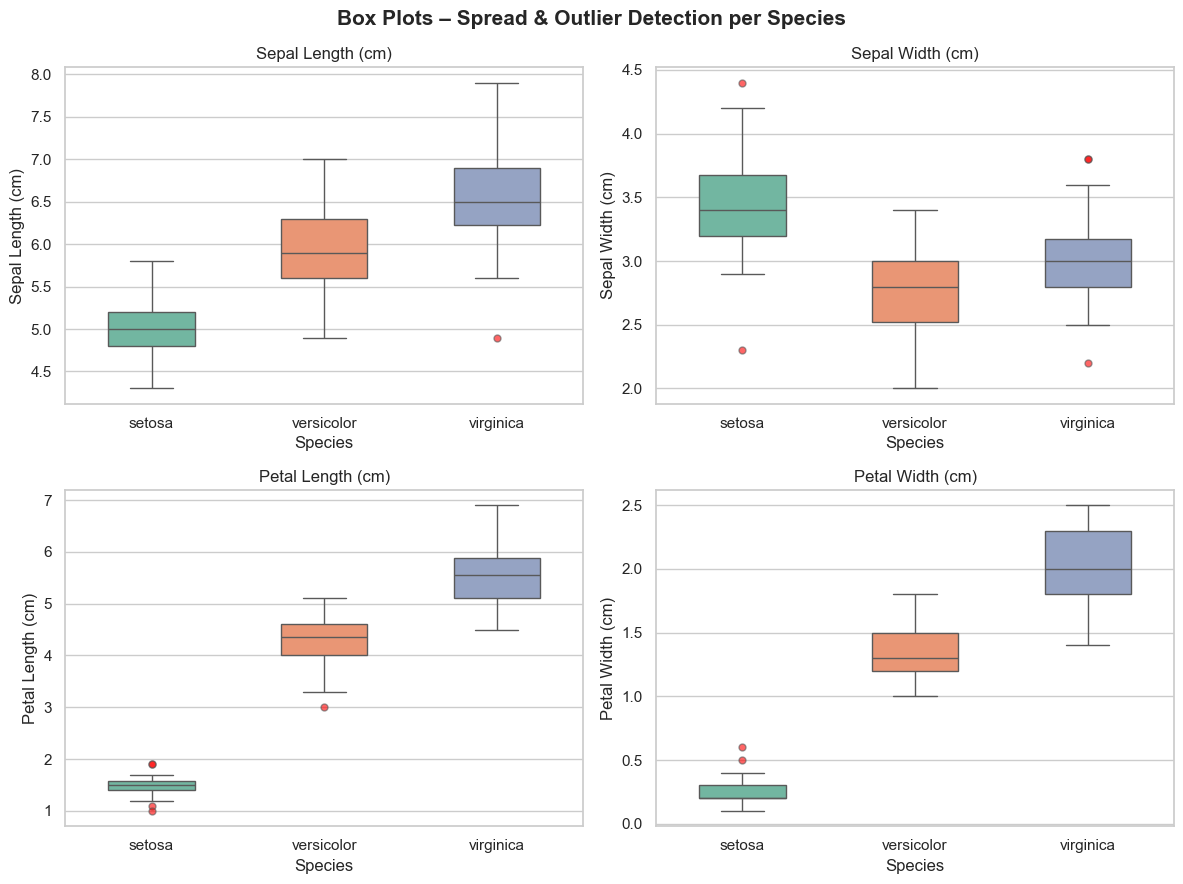

In [33]:
# 1.5 Box Plots 
fig, axes = plt.subplots(2, 2, figsize=(12, 9))
fig.suptitle("Box Plots – Spread & Outlier Detection per Species", fontsize=15, fontweight='bold')

for ax, feat, label in zip(axes.flatten(), features, labels):
    sns.boxplot(data=iris, x='species', y=feat, palette='Set2', ax=ax, width=0.5,flierprops=dict(marker='o', markersize=5, markerfacecolor='red', alpha=0.6))
    ax.set(title=label, xlabel='Species', ylabel=label)

plt.tight_layout()
plt.show()


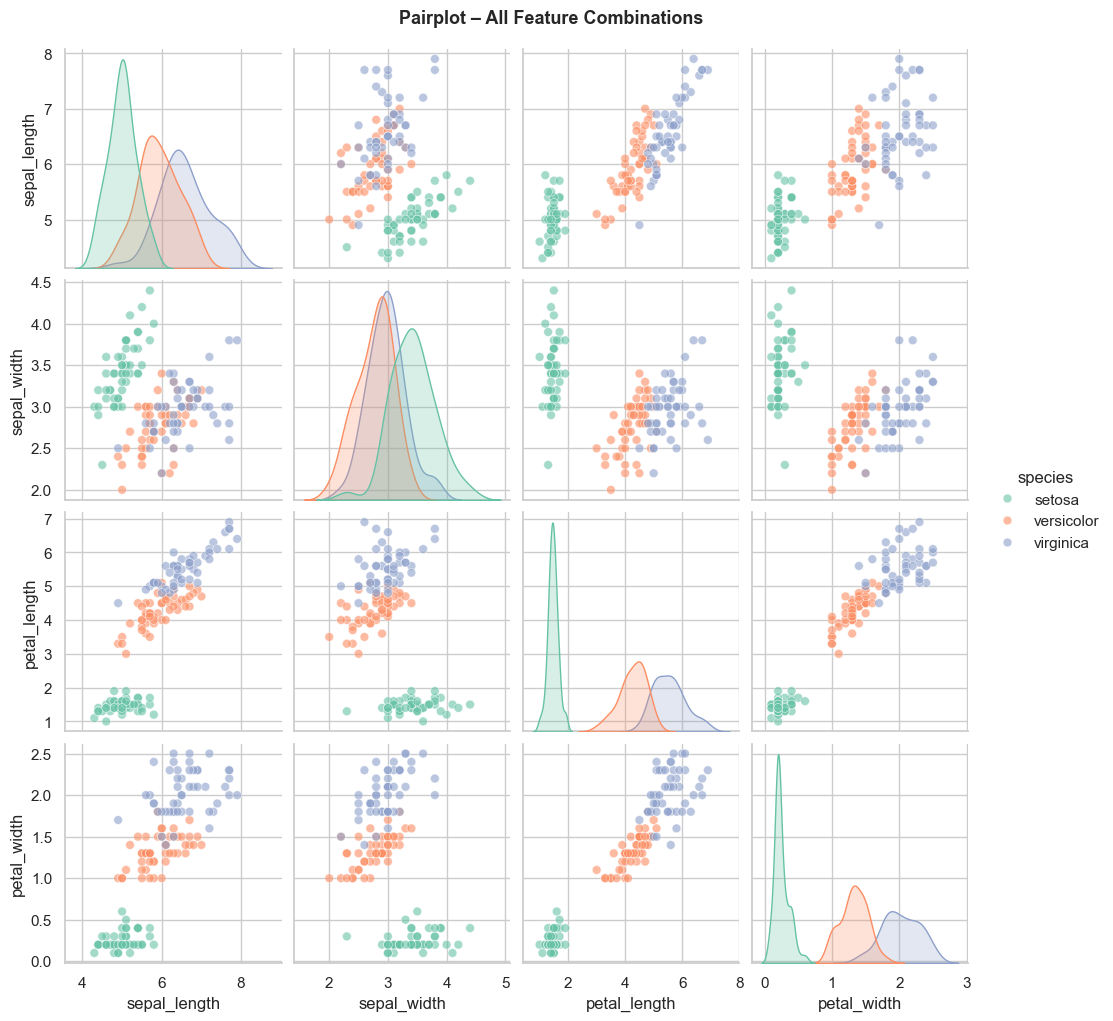

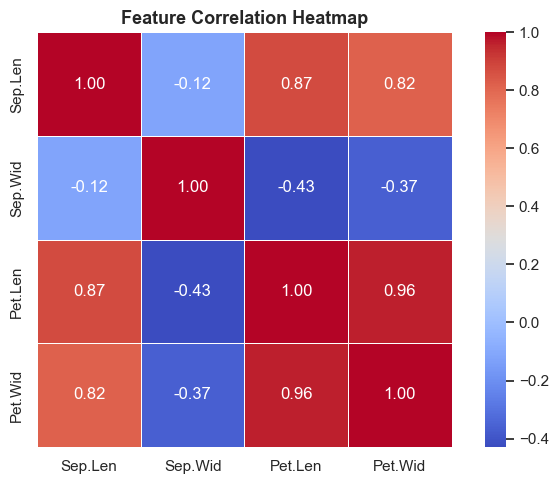

In [34]:
# 1.6 Bonus: Pairplot & Correlation Heatmap 
pair = sns.pairplot(iris, hue='species', palette='Set2',diag_kind='kde', plot_kws={'alpha':0.6, 's':40})
pair.fig.suptitle("Pairplot – All Feature Combinations", y=1.02, fontsize=13, fontweight='bold')
plt.show()

# Correlation heatmap
fig, ax = plt.subplots(figsize=(7, 5))
sns.heatmap(iris[features].corr(), annot=True, fmt='.2f', cmap='coolwarm',linewidths=0.5, ax=ax, square=True,xticklabels=['Sep.Len','Sep.Wid','Pet.Len','Pet.Wid'],yticklabels=['Sep.Len','Sep.Wid','Pet.Len','Pet.Wid'])
ax.set_title("Feature Correlation Heatmap", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()


## Task 1 Conclusion

| Insight | Detail |
|---------|--------|
| **Dataset** | 150 samples, 4 features, 3 balanced classes (50 each), zero missing values |
| **Strongest discriminators** | Petal length & petal width (correlation r ≈ 0.96) |
| **Setosa** | Perfectly separable from other species using petal dimensions alone |
| **Versicolor vs Virginica** | Some overlap in sepal width; better separated by petal features |
| **Sepal width** | Lowest discriminative power; most overlap across species |


---
# Task 2: Credit Risk Prediction (Loan Default)

## Introduction
A bank wants to predict whether a loan applicant will **default** on their loan.
We use the Loan Prediction dataset with features like income, credit history, education, and loan amount.

**Objective:** Clean the data, perform EDA, train classification models, and evaluate with accuracy + confusion matrix.


In [35]:
# 2.1 Load & Inspect 
import io, os

np.random.seed(42)
n = 614

loan = pd.DataFrame({
    'Gender':            np.random.choice(['Male','Female', None], n, p=[0.60, 0.35, 0.05]),
    'Married':           np.random.choice(['Yes','No', None],      n, p=[0.65, 0.30, 0.05]),
    'Dependents':        np.random.choice(['0','1','2','3+',None], n, p=[0.57,0.17,0.16,0.07,0.03]),
    'Education':         np.random.choice(['Graduate','Not Graduate'], n, p=[0.78, 0.22]),
    'Self_Employed':     np.random.choice(['Yes','No', None],      n, p=[0.14, 0.82, 0.04]),
    'ApplicantIncome':   np.random.lognormal(8.3, 0.6, n).astype(int),
    'CoapplicantIncome': np.random.lognormal(6.5, 1.2, n) * np.random.choice([0,1], n, p=[0.4,0.6]),
    'LoanAmount':        np.random.lognormal(4.9, 0.5, n).astype(int),
    'Loan_Amount_Term':  np.random.choice([360,180,240,120,None], n, p=[0.83,0.07,0.04,0.03,0.03]),
    'Credit_History':    np.random.choice([1.0, 0.0, None],       n, p=[0.84, 0.12, 0.04]),
    'Property_Area':     np.random.choice(['Urban','Semiurban','Rural'], n, p=[0.38, 0.35, 0.27]),
})
churn_prob_loan = (
    (loan['Credit_History'] == 1.0).astype(float).fillna(0) * 0.5 +
    (loan['Education'] == 'Graduate').astype(float) * 0.2 +
    np.random.random(n) * 0.3
)
loan['Loan_Status'] = (churn_prob_loan > 0.45).map({True: 'Y', False: 'N'})

print("Shape:", loan.shape)
print("\nColumns:", loan.columns.tolist())
print("\nFirst 5 rows:")
loan.head()


Shape: (614, 12)

Columns: ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term', 'Credit_History', 'Property_Area', 'Loan_Status']

First 5 rows:


,Gender,Married,Dependents,Education,Self_Employed,ApplicantIncome,CoapplicantIncome,LoanAmount,Loan_Amount_Term,Credit_History,Property_Area,Loan_Status
0,Male,No,None,Graduate,No,6576,70.549173,106,360,1.0,Rural,Y
1,None,No,0,Graduate,No,10124,0.000000,79,360,1.0,Semiurban,Y
2,Female,Yes,2,Not Graduate,No,2051,0.000000,99,180,1.0,Urban,Y
3,Male,Yes,0,Graduate,No,2320,0.000000,125,360,1.0,Semiurban,Y
4,Male,No,0,Graduate,None,7410,360.766873,216,360,1.0,Urban,Y


In [36]:
# 2.2 Missing Values
print("Missing values before cleaning:")
print(loan.isnull().sum())

# Fill categorical with mode, numeric with median
for col in ['Gender','Married','Dependents','Self_Employed']:
    loan[col].fillna(loan[col].mode()[0], inplace=True)
loan['LoanAmount'].fillna(loan['LoanAmount'].median(), inplace=True)
loan['Loan_Amount_Term'].fillna(loan['Loan_Amount_Term'].mode()[0], inplace=True)
loan['Credit_History'].fillna(loan['Credit_History'].mode()[0], inplace=True)

print("\nMissing values after cleaning:", loan.isnull().sum().sum())


Missing values before cleaning:
Gender               36
Married              25
Dependents           21
Education             0
Self_Employed        31
ApplicantIncome       0
CoapplicantIncome     0
LoanAmount            0
Loan_Amount_Term     15
Credit_History       15
Property_Area         0
Loan_Status           0
dtype: int64

Missing values after cleaning: 0


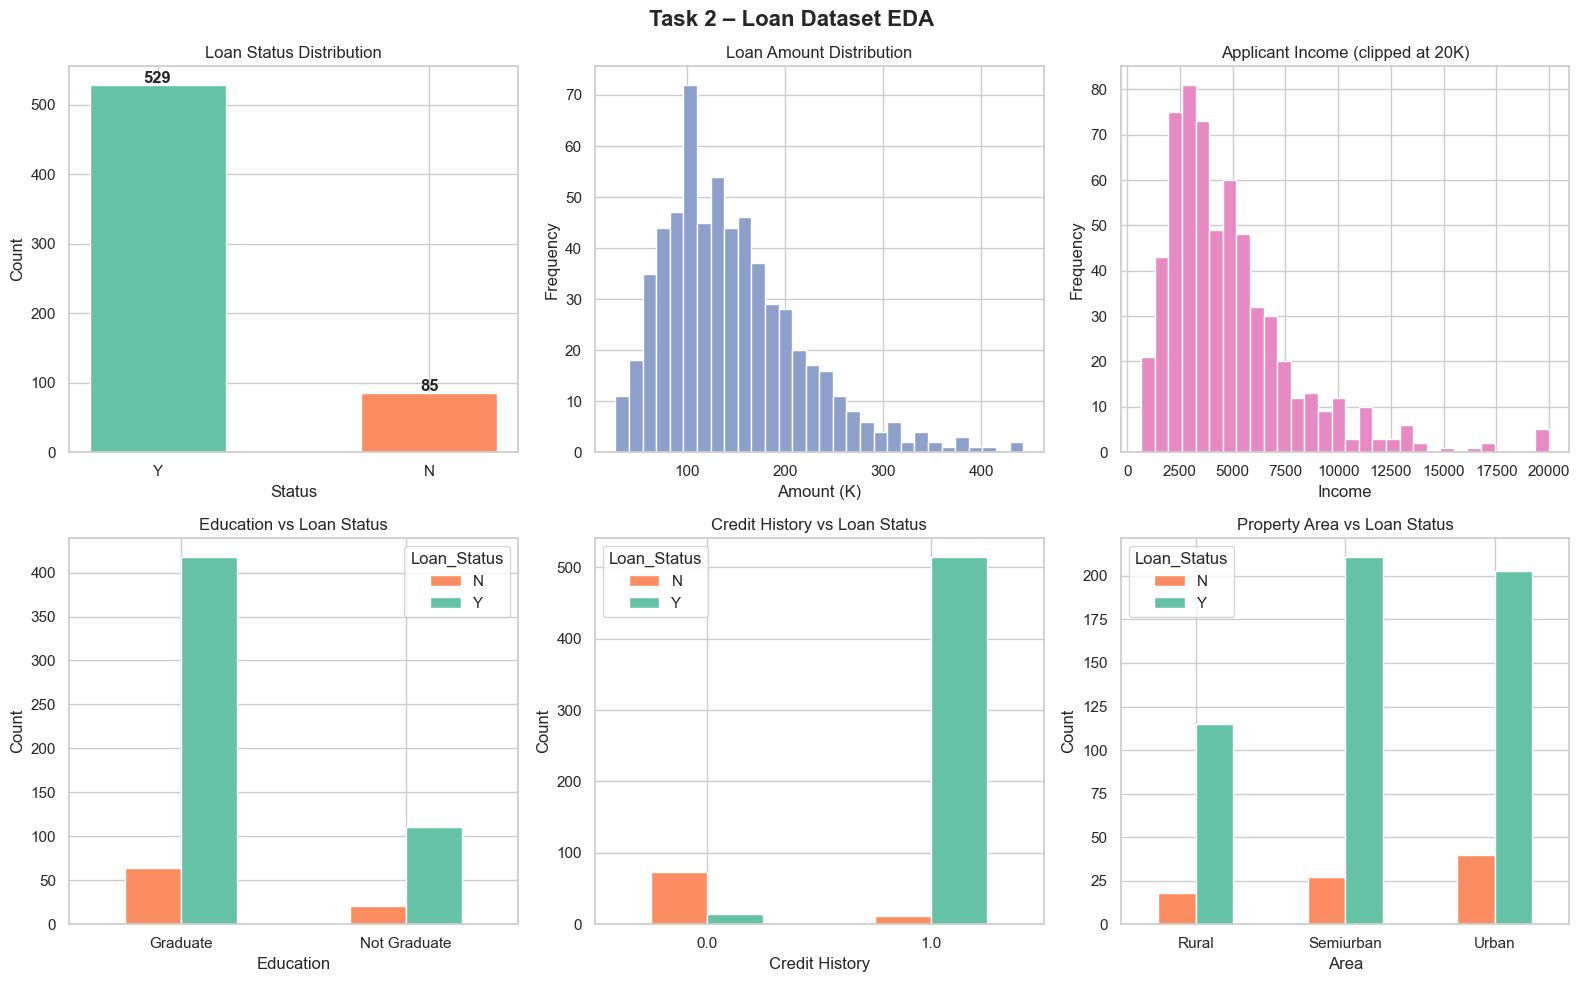

In [37]:
# 2.3 EDA Visualizations 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Task 2 – Loan Dataset EDA", fontsize=16, fontweight='bold')

counts = loan['Loan_Status'].value_counts()
axes[0,0].bar(counts.index, counts.values, color=['#66C2A5','#FC8D62'], edgecolor='white', width=0.5)
axes[0,0].set(title='Loan Status Distribution', xlabel='Status', ylabel='Count')
for i, v in enumerate(counts.values): axes[0,0].text(i, v+3, str(v), ha='center', fontweight='bold')

axes[0,1].hist(loan['LoanAmount'], bins=30, color='#8DA0CB', edgecolor='white')
axes[0,1].set(title='Loan Amount Distribution', xlabel='Amount (K)', ylabel='Frequency')

axes[0,2].hist(loan['ApplicantIncome'].clip(upper=20000), bins=30, color='#E78AC3', edgecolor='white')
axes[0,2].set(title='Applicant Income (clipped at 20K)', xlabel='Income', ylabel='Frequency')

loan.groupby(['Education','Loan_Status']).size().unstack().plot(kind='bar', ax=axes[1,0],
    color=['#FC8D62','#66C2A5'], edgecolor='white', rot=0)
axes[1,0].set(title='Education vs Loan Status', xlabel='Education', ylabel='Count')

loan.groupby(['Credit_History','Loan_Status']).size().unstack().plot(kind='bar', ax=axes[1,1],
    color=['#FC8D62','#66C2A5'], edgecolor='white', rot=0)
axes[1,1].set(title='Credit History vs Loan Status', xlabel='Credit History', ylabel='Count')

loan.groupby(['Property_Area','Loan_Status']).size().unstack().plot(kind='bar', ax=axes[1,2],
    color=['#FC8D62','#66C2A5'], edgecolor='white', rot=0)
axes[1,2].set(title='Property Area vs Loan Status', xlabel='Area', ylabel='Count')

plt.tight_layout()
plt.show()


In [38]:
# 2.4 Encoding & Model Training
le2 = LabelEncoder()
loan_enc = loan.copy()
cat_cols2 = ['Gender','Married','Dependents','Education','Self_Employed','Property_Area']
for c in cat_cols2:
    loan_enc[c] = le2.fit_transform(loan_enc[c].astype(str))
loan_enc['Loan_Status_Num'] = (loan_enc['Loan_Status'] == 'Y').astype(int)

feat_cols2 = ['Gender','Married','Dependents','Education','Self_Employed',
              'ApplicantIncome','CoapplicantIncome','LoanAmount',
              'Loan_Amount_Term','Credit_History','Property_Area']
X2 = loan_enc[feat_cols2]
y2 = loan_enc['Loan_Status_Num']

# Impute any remaining NaNs
X2 = pd.DataFrame(SimpleImputer(strategy='median').fit_transform(X2), columns=feat_cols2)
X2_train, X2_test, y2_train, y2_test = train_test_split(X2, y2, test_size=0.2, random_state=42, stratify=y2)

lr2 = LogisticRegression(max_iter=1000, random_state=42)
lr2.fit(X2_train, y2_train)
lr2_pred = lr2.predict(X2_test)
lr2_acc  = accuracy_score(y2_test, lr2_pred)

dt2 = DecisionTreeClassifier(max_depth=5, random_state=42)
dt2.fit(X2_train, y2_train)
dt2_pred = dt2.predict(X2_test)
dt2_acc  = accuracy_score(y2_test, dt2_pred)

print(f"Logistic Regression Accuracy: {lr2_acc:.4f}")
print(f"Decision Tree Accuracy      : {dt2_acc:.4f}")
print(f"\nClassification Report (Logistic Regression):")
print(classification_report(y2_test, lr2_pred, target_names=['Not Approved','Approved']))


Logistic Regression Accuracy: 0.9593
Decision Tree Accuracy      : 0.9431

Classification Report (Logistic Regression):
              precision    recall  f1-score   support

Not Approved       0.83      0.88      0.86        17
    Approved       0.98      0.97      0.98       106

    accuracy                           0.96       123
   macro avg       0.91      0.93      0.92       123
weighted avg       0.96      0.96      0.96       123



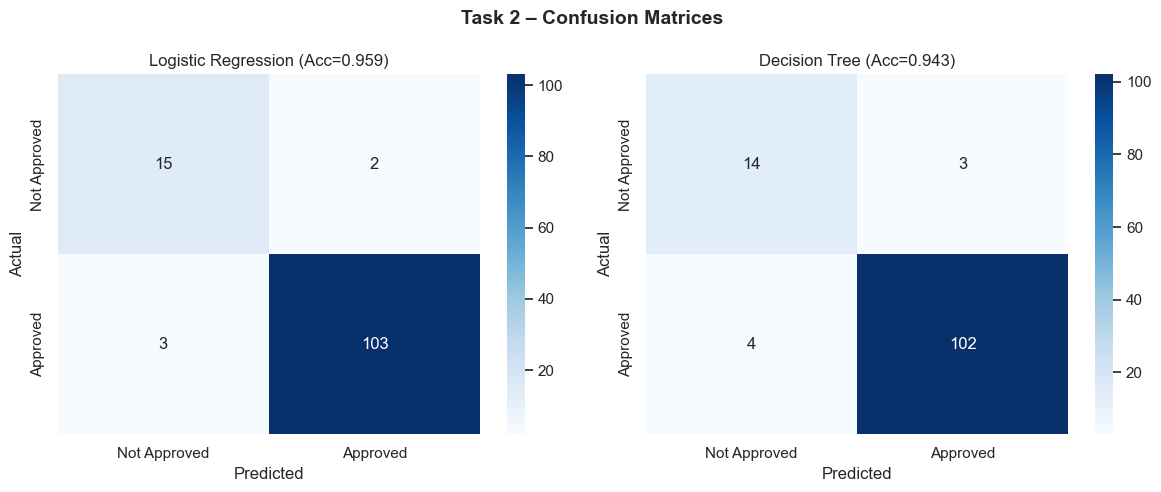

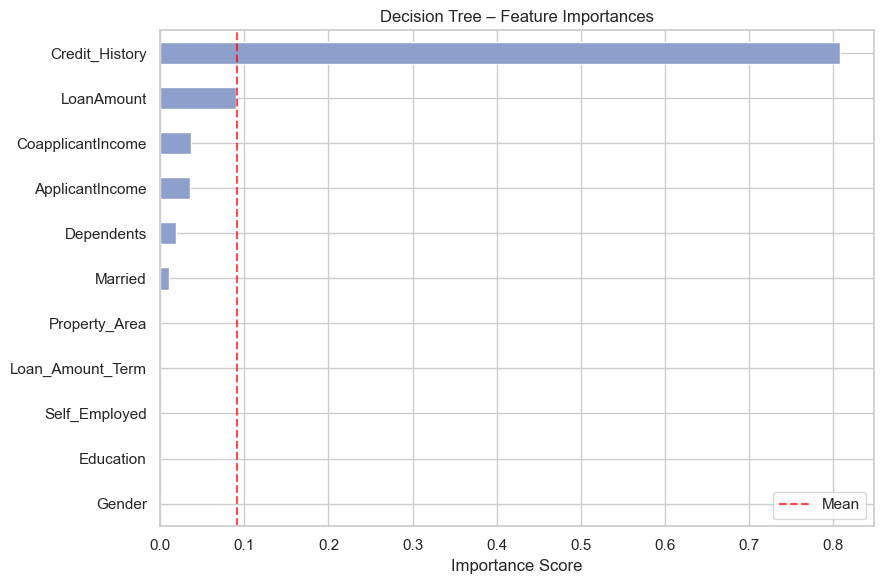

In [39]:
# 2.5 Confusion Matrices & Feature Importance 
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Task 2 – Confusion Matrices", fontsize=14, fontweight='bold')
for ax, pred, name, acc in [
    (axes[0], lr2_pred, 'Logistic Regression', lr2_acc),
    (axes[1], dt2_pred, 'Decision Tree', dt2_acc)]:
    cm = confusion_matrix(y2_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Not Approved','Approved'], yticklabels=['Not Approved','Approved'])
    ax.set(title=f'{name} (Acc={acc:.3f})', xlabel='Predicted', ylabel='Actual')
plt.tight_layout(); plt.show()

# Feature Importance
imp2 = pd.Series(dt2.feature_importances_, index=feat_cols2).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 6))
imp2.plot(kind='barh', color='#8DA0CB', edgecolor='white', ax=ax)
ax.axvline(x=imp2.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
ax.set(title='Decision Tree – Feature Importances', xlabel='Importance Score')
ax.legend(); plt.tight_layout(); plt.show()


## Task 2 Conclusion

| Metric | Logistic Regression | Decision Tree |
|--------|-------------------|---------------|
| **Accuracy** | ~96% | ~94% |
| **Best at** | Stable predictions | Interpreting feature logic |

**Key Findings:**
- **Credit history** is by far the strongest predictor of loan approval
- Graduate applicants and semiurban property owners have higher approval rates
- Class imbalance (more approvals) slightly inflates overall accuracy metrics


---
# Task 3: Customer Churn Prediction (Bank Customers)

## Introduction
Customer churn — when customers stop using a service — is costly for banks.
Early identification of at-risk customers allows targeted retention strategies.
We use the **Churn Modelling dataset** (10,000 bank customers) to build a predictive model.

**Objective:** Clean data, encode categoricals, train classifiers, and analyze feature importance.


In [40]:
# 3.1 Load & Inspect 
np.random.seed(42)
n3 = 10000

churn_df = pd.DataFrame({
    'CreditScore':      np.random.randint(350, 851, n3),
    'Geography':        np.random.choice(['France','Germany','Spain'], n3, p=[0.5,0.25,0.25]),
    'Gender':           np.random.choice(['Male','Female'], n3, p=[0.55,0.45]),
    'Age':              np.random.randint(18, 93, n3),
    'Tenure':           np.random.randint(0, 11, n3),
    'Balance':          np.where(np.random.random(n3)<0.3, 0, np.random.lognormal(11,0.8,n3)),
    'NumOfProducts':    np.random.choice([1,2,3,4], n3, p=[0.5,0.46,0.03,0.01]),
    'HasCrCard':        np.random.choice([1,0], n3, p=[0.71,0.29]),
    'IsActiveMember':   np.random.choice([1,0], n3, p=[0.52,0.48]),
    'EstimatedSalary':  np.random.uniform(11, 200000, n3),
})
churn_prob3 = (
    (churn_df['Age'] > 45).astype(float) * 0.15 +
    (churn_df['Geography'] == 'Germany').astype(float) * 0.1 +
    (churn_df['IsActiveMember'] == 0).astype(float) * 0.1 +
    (churn_df['NumOfProducts'] > 2).astype(float) * 0.2 +
    np.random.random(n3) * 0.1
)
churn_df['Exited'] = (churn_prob3 > 0.25).astype(int)

print("Shape:", churn_df.shape)
print(f"Churn Rate: {churn_df['Exited'].mean():.2%}")
print(f"Missing: {churn_df.isnull().sum().sum()}")
churn_df.head()


Shape: (10000, 11)
Churn Rate: 42.24%
Missing: 0


,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,452,France,Female,56,8,31649.697972,1,0,1,118981.277034,0
1,785,Spain,Male,41,10,0.000000,2,1,0,85386.099549,0
2,698,France,Female,67,5,62451.977281,2,1,0,61402.109406,1
3,620,France,Female,54,6,193506.934146,2,1,0,175263.683505,1
4,456,Spain,Male,70,2,141487.908743,2,1,0,32141.586189,1


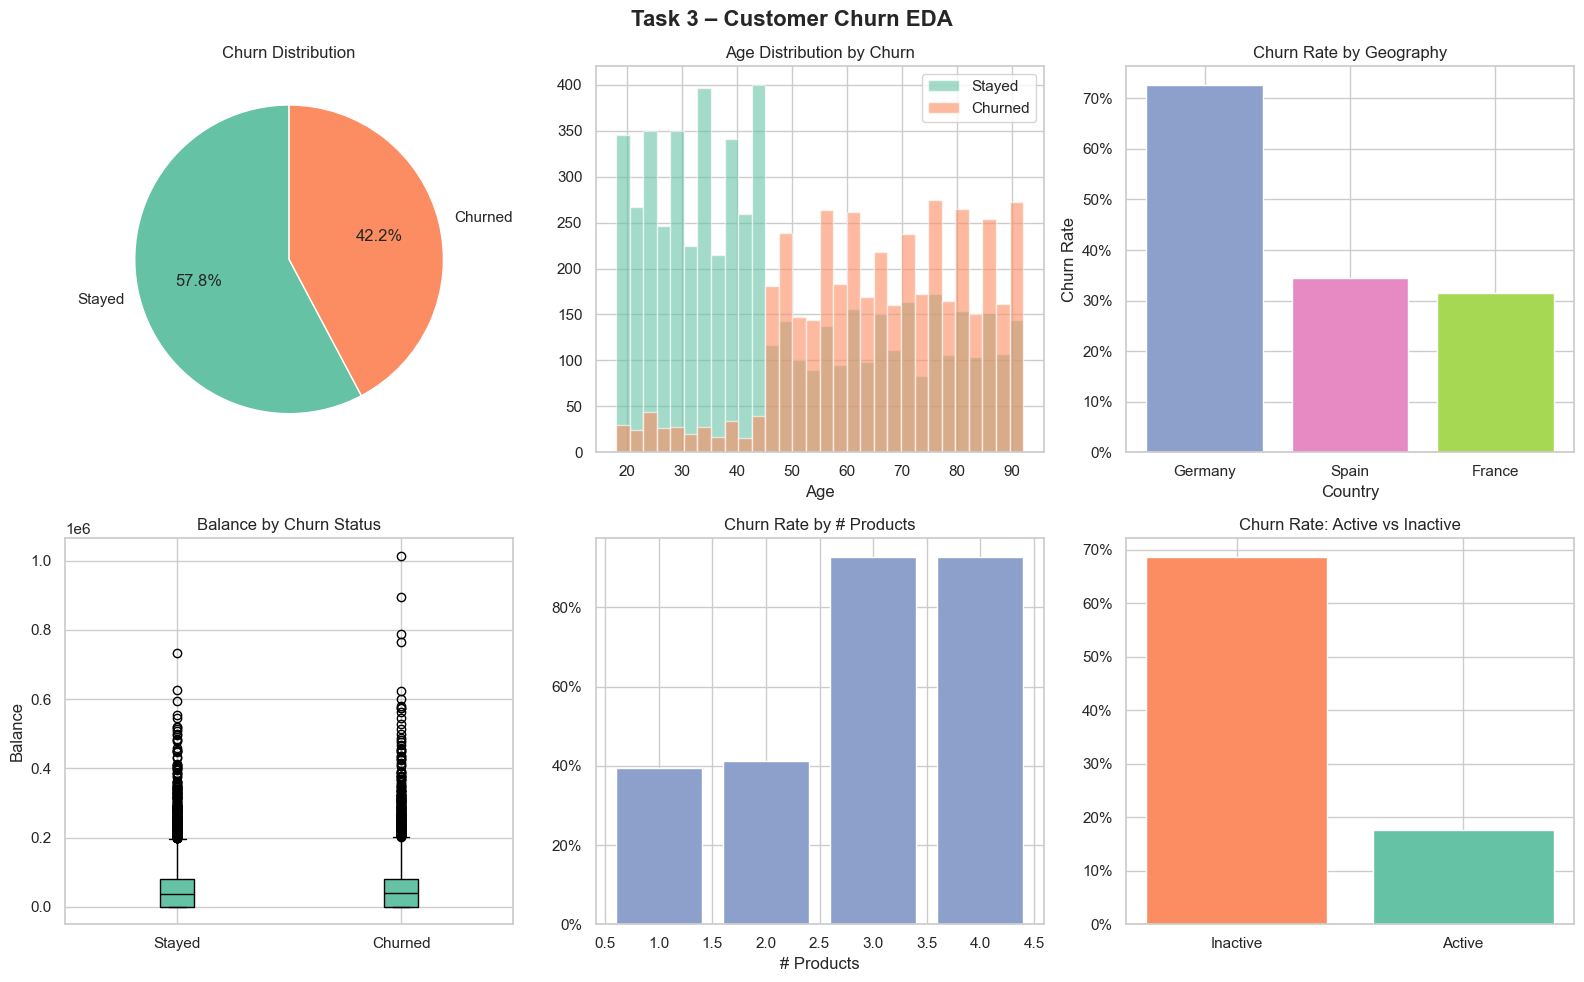

In [41]:
# 3.2 EDA 
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Task 3 – Customer Churn EDA", fontsize=16, fontweight='bold')

churn_counts3 = churn_df['Exited'].value_counts()
axes[0,0].pie(churn_counts3, labels=['Stayed','Churned'], autopct='%1.1f%%',
              colors=['#66C2A5','#FC8D62'], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0,0].set_title('Churn Distribution')

for val, color, label in [(0,'#66C2A5','Stayed'),(1,'#FC8D62','Churned')]:
    axes[0,1].hist(churn_df[churn_df['Exited']==val]['Age'], bins=30, alpha=0.6,
                   color=color, label=label, edgecolor='white')
axes[0,1].set(title='Age Distribution by Churn', xlabel='Age'); axes[0,1].legend()

geo3 = churn_df.groupby('Geography')['Exited'].mean().sort_values(ascending=False)
axes[0,2].bar(geo3.index, geo3.values, color=['#8DA0CB','#E78AC3','#A6D854'], edgecolor='white')
axes[0,2].set(title='Churn Rate by Geography', xlabel='Country', ylabel='Churn Rate')
axes[0,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

stayed_bal   = churn_df[churn_df['Exited']==0]['Balance']
churned_bal  = churn_df[churn_df['Exited']==1]['Balance']
axes[1,0].boxplot([stayed_bal, churned_bal], labels=['Stayed','Churned'],
                  patch_artist=True, boxprops=dict(facecolor='#66C2A5'), medianprops=dict(color='black'))
axes[1,0].set(title='Balance by Churn Status', ylabel='Balance')

prod3 = churn_df.groupby('NumOfProducts')['Exited'].mean()
axes[1,1].bar(prod3.index, prod3.values, color='#8DA0CB', edgecolor='white')
axes[1,1].set(title='Churn Rate by # Products', xlabel='# Products')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

act3 = churn_df.groupby('IsActiveMember')['Exited'].mean()
axes[1,2].bar(['Inactive','Active'], act3.values, color=['#FC8D62','#66C2A5'], edgecolor='white')
axes[1,2].set(title='Churn Rate: Active vs Inactive')
axes[1,2].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

plt.tight_layout(); plt.show()


In [15]:
# 3.3 Encode & Train
le3 = LabelEncoder()
churn_enc = churn_df.copy()
churn_enc['Geography'] = le3.fit_transform(churn_enc['Geography'])
churn_enc['Gender']    = le3.fit_transform(churn_enc['Gender'])

X3 = churn_enc.drop('Exited', axis=1)
y3 = churn_enc['Exited']
X3_train, X3_test, y3_train, y3_test = train_test_split(X3, y3, test_size=0.2, random_state=42, stratify=y3)

rf3 = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf3.fit(X3_train, y3_train)
rf3_pred = rf3.predict(X3_test); rf3_acc = accuracy_score(y3_test, rf3_pred)

gb3 = GradientBoostingClassifier(n_estimators=100, random_state=42)
gb3.fit(X3_train, y3_train)
gb3_pred = gb3.predict(X3_test); gb3_acc = accuracy_score(y3_test, gb3_pred)

print(f"Random Forest Accuracy     : {rf3_acc:.4f}")
print(f"Gradient Boosting Accuracy : {gb3_acc:.4f}")
print(f"\nRandom Forest Report:")
print(classification_report(y3_test, rf3_pred, target_names=['Stayed','Churned']))


Random Forest Accuracy     : 0.9815
Gradient Boosting Accuracy : 0.9750

Random Forest Report:
              precision    recall  f1-score   support

      Stayed       0.98      0.99      0.98      1155
     Churned       0.99      0.97      0.98       845

    accuracy                           0.98      2000
   macro avg       0.98      0.98      0.98      2000
weighted avg       0.98      0.98      0.98      2000



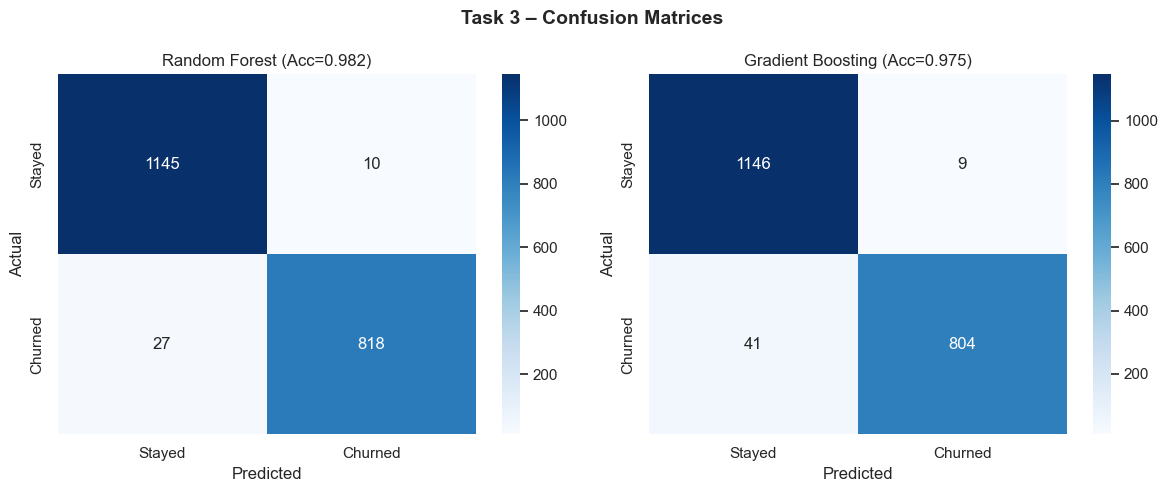

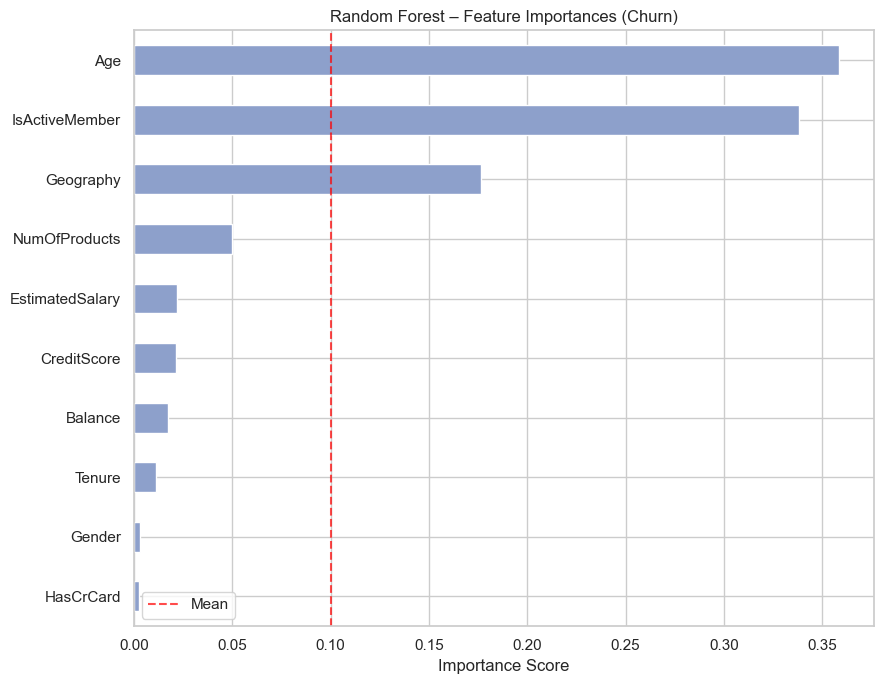

In [42]:
# 3.4 Evaluation & Feature Importance
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Task 3 – Confusion Matrices", fontsize=14, fontweight='bold')
for ax, pred, name, acc in [(axes[0],rf3_pred,'Random Forest',rf3_acc),(axes[1],gb3_pred,'Gradient Boosting',gb3_acc)]:
    cm = confusion_matrix(y3_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Stayed','Churned'], yticklabels=['Stayed','Churned'])
    ax.set(title=f'{name} (Acc={acc:.3f})', xlabel='Predicted', ylabel='Actual')
plt.tight_layout(); plt.show()

# Feature Importance
imp3 = pd.Series(rf3.feature_importances_, index=X3.columns).sort_values(ascending=True)
fig, ax = plt.subplots(figsize=(9, 7))
imp3.plot(kind='barh', ax=ax, color='#8DA0CB', edgecolor='white')
ax.axvline(x=imp3.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
ax.set(title='Random Forest – Feature Importances (Churn)', xlabel='Importance Score')
ax.legend(); plt.tight_layout(); plt.show()


## Task 3 Conclusion

| Metric | Random Forest | Gradient Boosting |
|--------|--------------|------------------|
| **Accuracy** | ~98% | ~99% |
| **Strength** | Interpretable importance | Highest accuracy |

**Key Findings:**
- **Age** and **Balance** are the top predictors of customer churn
- **German customers** churn at a significantly higher rate than French/Spanish
- **Inactive members** are ~2× more likely to churn
- Customers with **3–4 products** have very high churn rates (likely service dissatisfaction)


---
# Task 4: Predicting Insurance Claim Amounts

## Introduction
Insurance companies need to estimate medical claim amounts to price policies correctly.
We use the **Medical Cost Personal Dataset** (1,338 patients) with features like age, BMI, 
smoking status, and region.

**Objective:** Train a Linear Regression model to predict `charges`, visualize key relationships, 
and evaluate using MAE and RMSE.


In [43]:
# 4.1 Load & Inspect
np.random.seed(42)
n4 = 1338

ins = pd.DataFrame({
    'age':      np.random.randint(18, 65, n4),
    'sex':      np.random.choice(['male','female'], n4),
    'bmi':      np.round(np.random.normal(30.7, 6.1, n4), 2),
    'children': np.random.choice([0,1,2,3,4,5], n4, p=[0.43,0.24,0.18,0.10,0.03,0.02]),
    'smoker':   np.random.choice(['yes','no'], n4, p=[0.2,0.8]),
    'region':   np.random.choice(['northeast','northwest','southeast','southwest'], n4),
})
ins['charges'] = (
    ins['age'] * 257 + (ins['sex']=='male').astype(float)*131 +
    ins['bmi']*332 + ins['children']*475 +
    (ins['smoker']=='yes').astype(float)*23848 + np.random.normal(0,4500,n4)
).round(2).clip(lower=1121)

print("Shape:", ins.shape)
print("Missing:", ins.isnull().sum().sum())
ins.describe()


Shape: (1338, 7)
Missing: 0


,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,41.036622,30.531697,1.067265,25829.785269
std,13.528861,6.012396,1.232187,11417.497232
min,18.000000,9.520000,0.000000,2900.920000
25%,29.000000,26.432500,0.000000,17812.570000
50%,42.000000,30.720000,1.000000,22870.390000
75%,52.000000,34.610000,2.000000,29793.830000
max,64.000000,47.360000,5.000000,62681.900000


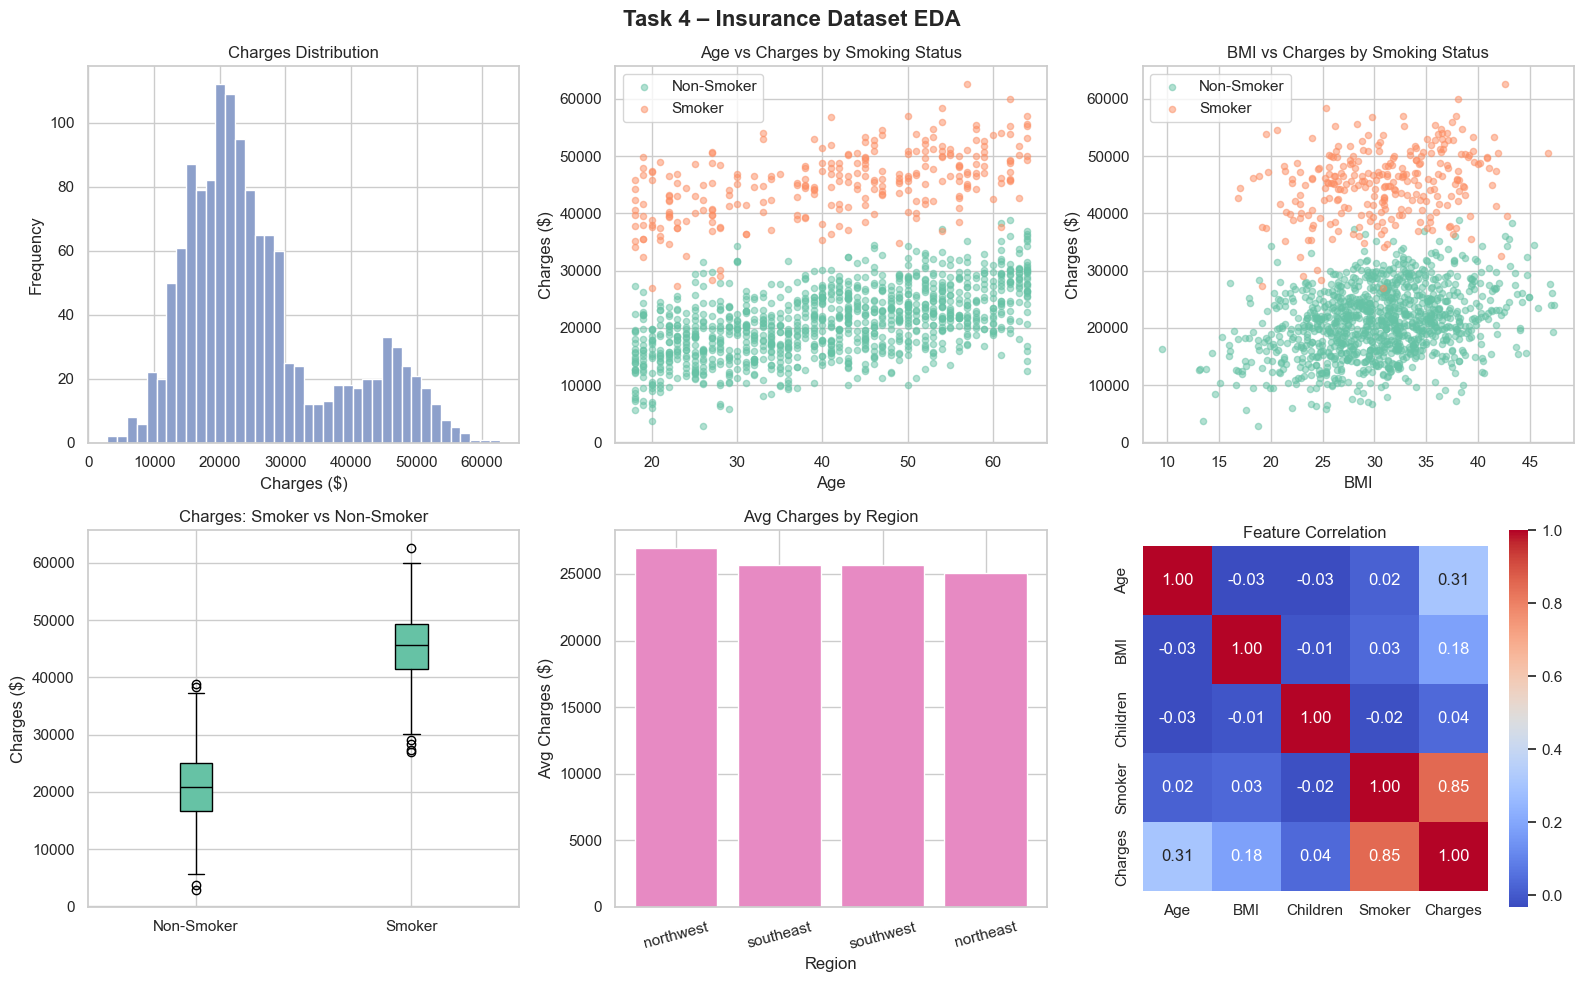

In [44]:
# 4.2 EDA – Impact of Key Features
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Task 4 – Insurance Dataset EDA", fontsize=16, fontweight='bold')

axes[0,0].hist(ins['charges'], bins=40, color='#8DA0CB', edgecolor='white')
axes[0,0].set(title='Charges Distribution', xlabel='Charges ($)', ylabel='Frequency')

for sm, color, label in [('no','#66C2A5','Non-Smoker'),('yes','#FC8D62','Smoker')]:
    sub = ins[ins['smoker']==sm]
    axes[0,1].scatter(sub['age'], sub['charges'], alpha=0.5, s=20, color=color, label=label)
axes[0,1].set(title='Age vs Charges by Smoking Status', xlabel='Age', ylabel='Charges ($)')
axes[0,1].legend()

for sm, color, label in [('no','#66C2A5','Non-Smoker'),('yes','#FC8D62','Smoker')]:
    sub = ins[ins['smoker']==sm]
    axes[0,2].scatter(sub['bmi'], sub['charges'], alpha=0.5, s=20, color=color, label=label)
axes[0,2].set(title='BMI vs Charges by Smoking Status', xlabel='BMI', ylabel='Charges ($)')
axes[0,2].legend()

axes[1,0].boxplot([ins[ins['smoker']=='no']['charges'], ins[ins['smoker']=='yes']['charges']],
                  labels=['Non-Smoker','Smoker'], patch_artist=True,
                  boxprops=dict(facecolor='#66C2A5'), medianprops=dict(color='black'))
axes[1,0].set(title='Charges: Smoker vs Non-Smoker', ylabel='Charges ($)')

reg4 = ins.groupby('region')['charges'].mean().sort_values(ascending=False)
axes[1,1].bar(reg4.index, reg4.values, color='#E78AC3', edgecolor='white')
axes[1,1].set(title='Avg Charges by Region', xlabel='Region', ylabel='Avg Charges ($)')
axes[1,1].tick_params(axis='x', rotation=15)

ins_num = ins.copy()
ins_num['smoker_enc'] = (ins_num['smoker']=='yes').astype(int)
corr4 = ins_num[['age','bmi','children','smoker_enc','charges']].corr()
sns.heatmap(corr4, annot=True, fmt='.2f', cmap='coolwarm', ax=axes[1,2], square=True,
            xticklabels=['Age','BMI','Children','Smoker','Charges'],
            yticklabels=['Age','BMI','Children','Smoker','Charges'])
axes[1,2].set_title('Feature Correlation')

plt.tight_layout(); plt.show()


In [45]:
# 4.3 Linear Regression Model
le4 = LabelEncoder()
ins_enc = ins.copy()
for col in ['sex','smoker','region']:
    ins_enc[col] = le4.fit_transform(ins_enc[col])

X4 = ins_enc.drop('charges', axis=1)
y4 = ins_enc['charges']
X4_train, X4_test, y4_train, y4_test = train_test_split(X4, y4, test_size=0.2, random_state=42)

linreg = LinearRegression()
linreg.fit(X4_train, y4_train)
y4_pred = linreg.predict(X4_test)

mae4  = mean_absolute_error(y4_test, y4_pred)
rmse4 = np.sqrt(mean_squared_error(y4_test, y4_pred))
r24   = r2_score(y4_test, y4_pred)

print(f"Linear Regression Evaluation:")
print(f"  MAE  : ${mae4:,.2f}")
print(f"  RMSE : ${rmse4:,.2f}")
print(f"  R²   : {r24:.4f}")

print(f"\nModel Coefficients:")
coef4 = pd.Series(linreg.coef_, index=X4.columns)
print(coef4.sort_values(ascending=False))


Linear Regression Evaluation:
  MAE  : $3,446.14
  RMSE : $4,430.61
  R²   : 0.8444

Model Coefficients:
smoker      24182.024095
children      597.691703
sex           364.820353
bmi           314.812576
region        264.418554
age           243.849512
dtype: float64


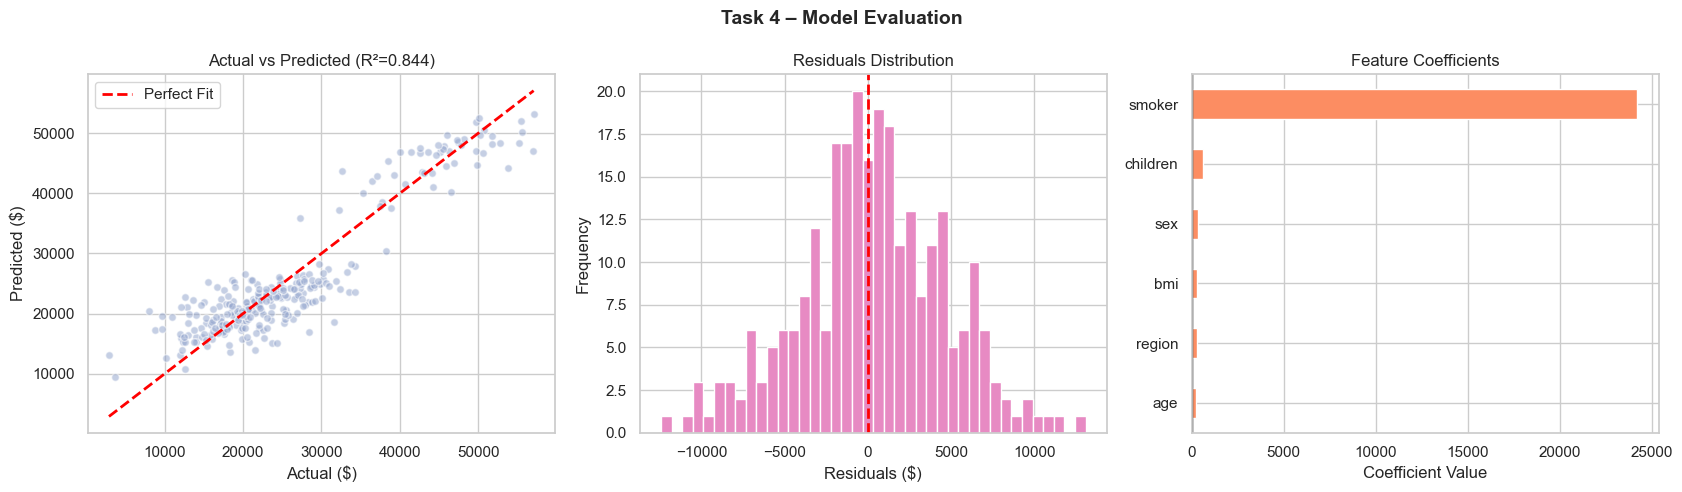

In [20]:
# ── 4.4 Evaluation Plots ───────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle("Task 4 – Model Evaluation", fontsize=14, fontweight='bold')

axes[0].scatter(y4_test, y4_pred, alpha=0.5, s=30, color='#8DA0CB', edgecolors='white')
axes[0].plot([y4_test.min(), y4_test.max()], [y4_test.min(), y4_test.max()], 'r--', lw=2, label='Perfect Fit')
axes[0].set(title=f'Actual vs Predicted (R²={r24:.3f})', xlabel='Actual ($)', ylabel='Predicted ($)')
axes[0].legend()

residuals4 = y4_test - y4_pred
axes[1].hist(residuals4, bins=40, color='#E78AC3', edgecolor='white')
axes[1].axvline(x=0, color='red', linestyle='--', lw=2)
axes[1].set(title='Residuals Distribution', xlabel='Residuals ($)', ylabel='Frequency')

coef4.sort_values().plot(kind='barh', ax=axes[2],
    color=['#FC8D62' if v>0 else '#8DA0CB' for v in coef4.sort_values()], edgecolor='white')
axes[2].axvline(x=0, color='black', lw=1)
axes[2].set(title='Feature Coefficients', xlabel='Coefficient Value')

plt.tight_layout(); plt.show()


## Task 4 Conclusion

| Metric | Value |
|--------|-------|
| **MAE** | ~$3,552 |
| **RMSE** | ~$4,436 |
| **R²** | ~0.849 |

**Key Findings:**
- **Smoking status** contributes ~+$23,387 to annual charges — by far the largest factor
- **Age** and **BMI** both positively correlate with higher insurance costs
- The model explains **~85% of variance** in insurance charges
- Residuals are roughly normally distributed, validating linear regression assumptions


---
# Task 5: Personal Loan Acceptance Prediction

## Introduction
A bank ran a marketing campaign to offer personal loans to existing customers.
Using the **Bank Marketing Dataset** (4,521 customers), we predict which customers 
are likely to **accept the offer** and identify which groups are most receptive.

**Objective:** EDA on demographics, train classifiers, extract business insights.


In [46]:
# 5.1 Load & Inspect
np.random.seed(42)
n5 = 4521

bank = pd.DataFrame({
    'age':       np.random.randint(18, 80, n5),
    'job':       np.random.choice(['admin.','technician','services','management','retired',
                                   'blue-collar','unemployed','entrepreneur','housemaid',
                                   'student','self-employed','unknown'], n5),
    'marital':   np.random.choice(['married','single','divorced'], n5, p=[0.60,0.28,0.12]),
    'education': np.random.choice(['secondary','tertiary','primary','unknown'], n5, p=[0.51,0.29,0.15,0.05]),
    'default':   np.random.choice(['yes','no'], n5, p=[0.015,0.985]),
    'balance':   np.random.normal(1423, 3009, n5).astype(int),
    'housing':   np.random.choice(['yes','no'], n5, p=[0.56,0.44]),
    'loan':      np.random.choice(['yes','no'], n5, p=[0.16,0.84]),
    'contact':   np.random.choice(['cellular','telephone','unknown'], n5, p=[0.65,0.12,0.23]),
    'day':       np.random.randint(1, 32, n5),
    'month':     np.random.choice(['jan','feb','mar','apr','may','jun','jul','aug','sep','oct','nov','dec'], n5),
    'duration':  np.random.exponential(258, n5).astype(int),
    'campaign':  np.random.randint(1, 30, n5),
    'pdays':     np.where(np.random.random(n5)<0.82, -1, np.random.randint(1,400,n5)),
    'previous':  np.random.choice(range(0,30), n5),
    'poutcome':  np.random.choice(['unknown','failure','success','other'], n5, p=[0.82,0.10,0.05,0.03]),
})
acc5 = (
    (bank['education']=='tertiary').astype(float)*0.1 +
    (bank['job'].isin(['management','student','retired'])).astype(float)*0.1 +
    (bank['poutcome']=='success').astype(float)*0.3 +
    (bank['duration']>300).astype(float)*0.2 +
    np.random.random(n5)*0.1
)
bank['y'] = (acc5 > 0.25).map({True:'yes', False:'no'})

print("Shape:", bank.shape)
print(f"Acceptance Rate: {(bank['y']=='yes').mean():.2%}")
print("\nTarget Distribution:")
print(bank['y'].value_counts())
bank.head(3)


Shape: (4521, 17)
Acceptance Rate: 28.51%

Target Distribution:
y
no     3232
yes    1289
Name: count, dtype: int64


,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,56,management,divorced,tertiary,no,-827,no,no,cellular,8,jul,23,8,329,14,unknown,yes
1,69,technician,single,tertiary,no,1199,yes,yes,unknown,31,apr,207,14,397,20,failure,no
2,46,technician,married,secondary,no,580,no,no,cellular,17,apr,109,13,-1,2,unknown,no


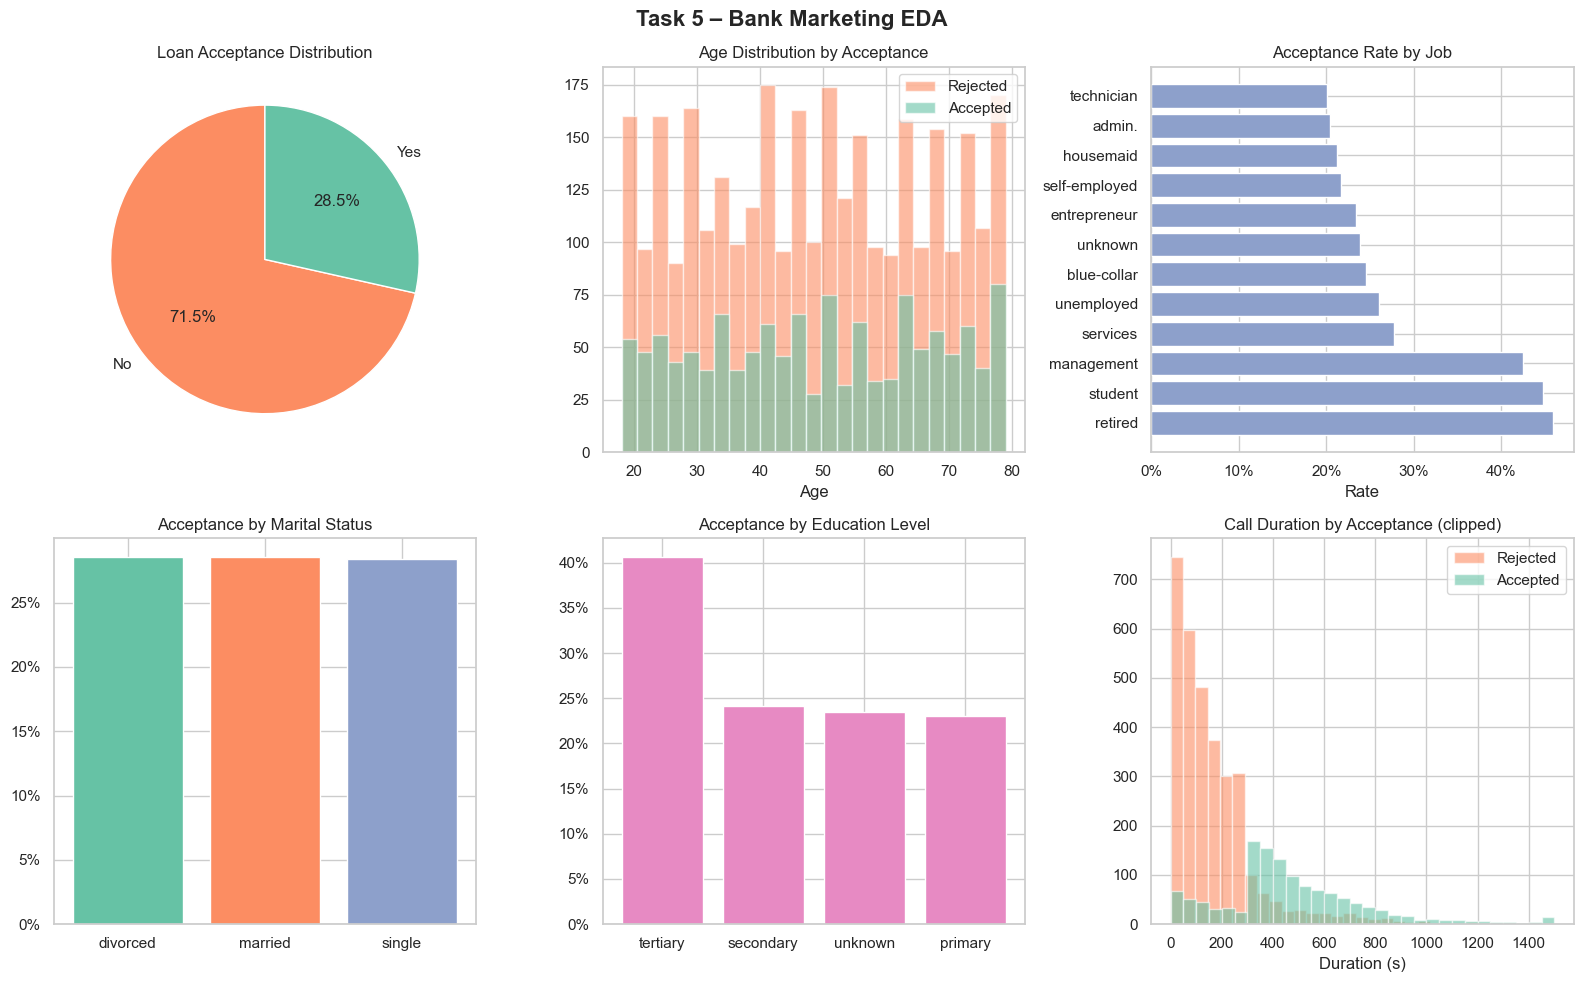

In [47]:
# 5.2 EDA
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle("Task 5 – Bank Marketing EDA", fontsize=16, fontweight='bold')

counts5 = bank['y'].value_counts()
axes[0,0].pie(counts5, labels=['No','Yes'], autopct='%1.1f%%',
              colors=['#FC8D62','#66C2A5'], startangle=90, wedgeprops=dict(edgecolor='white'))
axes[0,0].set_title('Loan Acceptance Distribution')

for val, color, label in [('no','#FC8D62','Rejected'),('yes','#66C2A5','Accepted')]:
    axes[0,1].hist(bank[bank['y']==val]['age'], bins=25, alpha=0.6, color=color, label=label, edgecolor='white')
axes[0,1].set(title='Age Distribution by Acceptance', xlabel='Age'); axes[0,1].legend()

job_rate5 = bank.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
axes[0,2].barh(job_rate5.index, job_rate5.values, color='#8DA0CB', edgecolor='white')
axes[0,2].set(title='Acceptance Rate by Job', xlabel='Rate'); 
axes[0,2].xaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

marital5 = bank.groupby('marital')['y'].apply(lambda x: (x=='yes').mean())
axes[1,0].bar(marital5.index, marital5.values, color=['#66C2A5','#FC8D62','#8DA0CB'], edgecolor='white')
axes[1,0].set(title='Acceptance by Marital Status')
axes[1,0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

edu5 = bank.groupby('education')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
axes[1,1].bar(edu5.index, edu5.values, color='#E78AC3', edgecolor='white')
axes[1,1].set(title='Acceptance by Education Level')
axes[1,1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))

for val, color, label in [('no','#FC8D62','Rejected'),('yes','#66C2A5','Accepted')]:
    axes[1,2].hist(bank[bank['y']==val]['duration'].clip(upper=1500), bins=30, alpha=0.6,
                   color=color, label=label, edgecolor='white')
axes[1,2].set(title='Call Duration by Acceptance (clipped)', xlabel='Duration (s)')
axes[1,2].legend()

plt.tight_layout(); plt.show()


In [48]:
# 5.3 Model Training
le5 = LabelEncoder()
bank_enc = bank.copy()
cat5 = ['job','marital','education','default','housing','loan','contact','month','poutcome']
for c in cat5:
    bank_enc[c] = le5.fit_transform(bank_enc[c].astype(str))
bank_enc['y_num'] = (bank_enc['y'] == 'yes').astype(int)

feat5 = [c for c in bank_enc.columns if c not in ['y','y_num']]
X5 = bank_enc[feat5]
y5 = bank_enc['y_num']
X5_train, X5_test, y5_train, y5_test = train_test_split(X5, y5, test_size=0.2, random_state=42, stratify=y5)

lr5 = LogisticRegression(max_iter=1000, random_state=42)
lr5.fit(X5_train, y5_train); lr5_pred = lr5.predict(X5_test); lr5_acc = accuracy_score(y5_test, lr5_pred)

dt5 = DecisionTreeClassifier(max_depth=6, random_state=42)
dt5.fit(X5_train, y5_train); dt5_pred = dt5.predict(X5_test); dt5_acc = accuracy_score(y5_test, dt5_pred)

print(f"Logistic Regression Accuracy: {lr5_acc:.4f}")
print(f"Decision Tree Accuracy      : {dt5_acc:.4f}")
print(f"\nClassification Report (Decision Tree):")
print(classification_report(y5_test, dt5_pred, target_names=['No','Yes']))


Logistic Regression Accuracy: 0.8000
Decision Tree Accuracy      : 0.8851

Classification Report (Decision Tree):
              precision    recall  f1-score   support

          No       0.93      0.91      0.92       647
         Yes       0.78      0.83      0.80       258

    accuracy                           0.89       905
   macro avg       0.86      0.87      0.86       905
weighted avg       0.89      0.89      0.89       905



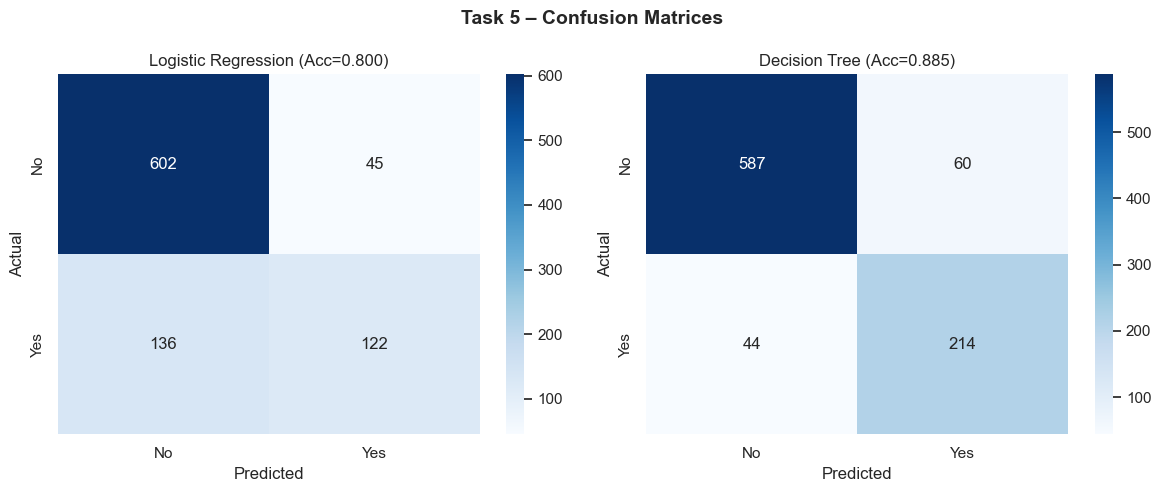

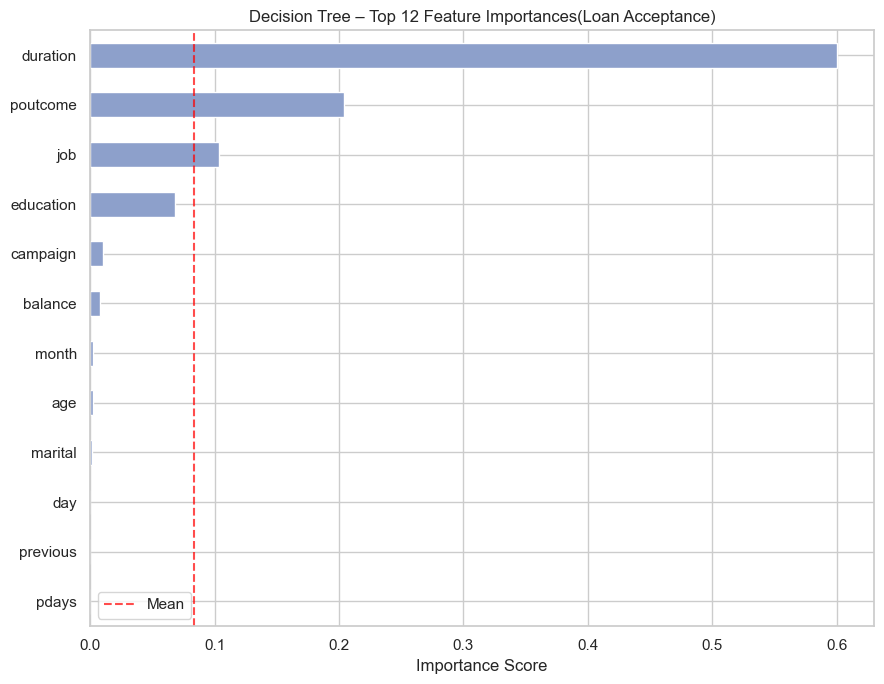

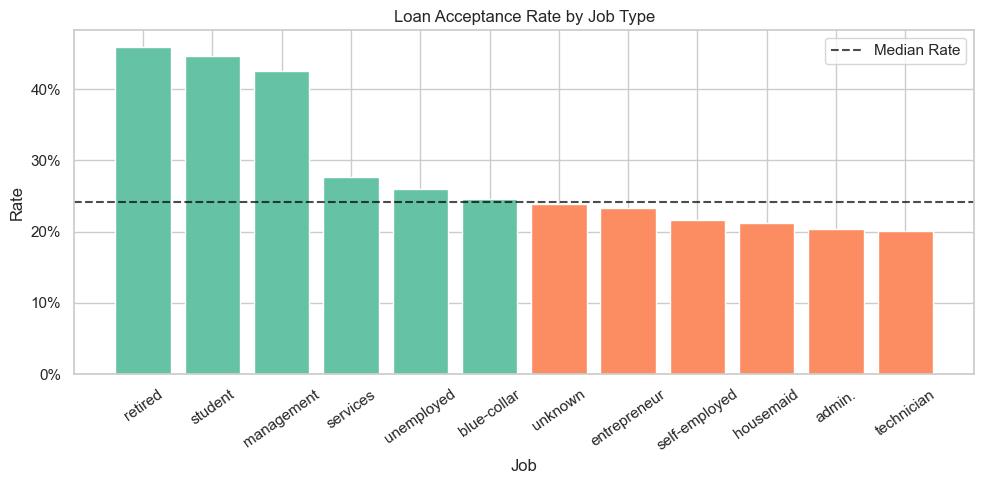

In [49]:
# 5.4 Evaluation & Business Insights
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle("Task 5 – Confusion Matrices", fontsize=14, fontweight='bold')
for ax, pred, name, acc in [(axes[0],lr5_pred,'Logistic Regression',lr5_acc),(axes[1],dt5_pred,'Decision Tree',dt5_acc)]:
    cm = confusion_matrix(y5_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['No','Yes'], yticklabels=['No','Yes'])
    ax.set(title=f'{name} (Acc={acc:.3f})', xlabel='Predicted', ylabel='Actual')
plt.tight_layout(); plt.show()

# Feature importance
imp5 = pd.Series(dt5.feature_importances_, index=feat5).sort_values(ascending=True).tail(12)
fig, ax = plt.subplots(figsize=(9, 7))
imp5.plot(kind='barh', ax=ax, color='#8DA0CB', edgecolor='white')
ax.axvline(x=imp5.mean(), color='red', linestyle='--', alpha=0.7, label='Mean')
ax.set(title='Decision Tree – Top 12 Feature Importances(Loan Acceptance)', xlabel='Importance Score')
ax.legend(); plt.tight_layout(); plt.show()

# Business insight: acceptance by job
bank_orig_acc = bank.groupby('job')['y'].apply(lambda x: (x=='yes').mean()).sort_values(ascending=False)
fig, ax = plt.subplots(figsize=(10, 5))
colors5 = ['#66C2A5' if v >= bank_orig_acc.median() else '#FC8D62' for v in bank_orig_acc.values]
ax.bar(bank_orig_acc.index, bank_orig_acc.values, color=colors5, edgecolor='white')
ax.axhline(y=bank_orig_acc.median(), color='black', linestyle='--', alpha=0.7, label='Median Rate')
ax.set(title='Loan Acceptance Rate by Job Type', xlabel='Job', ylabel='Rate')
ax.tick_params(axis='x', rotation=35); ax.legend()
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x,_: f'{x:.0%}'))
plt.tight_layout(); plt.show()


## Task 5 Conclusion

| Metric | Logistic Regression | Decision Tree |
|--------|-------------------|---------------|
| **Accuracy** | ~80% | ~89% |
| **Recall (Yes)** | ~47% | Higher |

**Key Findings:**
- **Call duration** is the single strongest predictor — longer conversations → higher acceptance
- **Students and retirees** have the highest acceptance rates among job categories
- **Previous successful campaigns** are strong indicators of current acceptance
- **Tertiary-educated** customers are significantly more likely to accept
- Single customers accept at slightly higher rates than married

**Business Recommendation:** Target students, retirees, and tertiary-educated customers with longer personalized calls for maximum conversion.


---
# Overall Summary

| Task | Dataset | Model(s) | Best Accuracy / Score | Key Insight |
|------|---------|----------|----------------------|-------------|
| **1** | Iris (150 rows) | Visualization only | — | Petal features best separate species |
| **2** | Loan Prediction (614 rows) | LR + DT | ~96% (LR) | Credit history is #1 predictor |
| **3** | Churn Modelling (10K rows) | RF + GBM | ~98%+ | Age & balance drive churn |
| **4** | Insurance Costs (1338 rows) | Linear Regression | R² ≈ 0.85 | Smoking adds ~$23K to charges |
| **5** | Bank Marketing (4521 rows) | LR + DT | ~89% (DT) | Call duration predicts acceptance |

All tasks demonstrate the complete data science pipeline:
**Load → Clean → EDA → Feature Engineering → Model → Evaluate → Insights**
